In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
import pickle

In [3]:
import pandas as pd

co2_df = pd.read_csv('https://raw.githubusercontent.com/stee1011/climate-hackathon/main/data.csv')
ch4_df = pd.read_csv('https://raw.githubusercontent.com/stee1011/climate-hackathon/main/data_ch4.csv')
n2o_df = pd.read_csv('https://raw.githubusercontent.com/stee1011/climate-hackathon/main/data_n2o.csv')

print("CO2 shape:", co2_df.shape)
print("CH4 shape:", ch4_df.shape)
print("N2O shape:", n2o_df.shape)

CO2 shape: (9794, 57)
CH4 shape: (9794, 57)
N2O shape: (9794, 57)


In [10]:
def extract_annual_totals(df, gas_name):
    year_cols = [col for col in df.columns if col.startswith('Y_')]
    annual = df[year_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0)
    annual.index = [int(col.replace('Y_', '')) for col in annual.index]
    annual.index = pd.to_datetime(annual.index, format='%Y')
    annual.name = gas_name
    return annual

co2_series = extract_annual_totals(co2_df, 'CO2')
ch4_series = extract_annual_totals(ch4_df, 'CH4')
n2o_series = extract_annual_totals(n2o_df, 'N2O')

print("CO2 first 5 values:")
print(co2_series.head())
print("\nCH4 first 5 values:")
print(ch4_series.head())
print("\nN2O first 5 values:")
print(n2o_series.head())

CO2 first 5 values:
1970-01-01    1.582627e+07
1971-01-01    1.578858e+07
1972-01-01    1.659201e+07
1973-01-01    1.756221e+07
1974-01-01    1.750286e+07
Name: CO2, dtype: float64

CH4 first 5 values:
1970-01-01    242758.369569
1971-01-01    246005.713681
1972-01-01    249381.191199
1973-01-01    255521.586254
1974-01-01    257294.013410
Name: CH4, dtype: float64

N2O first 5 values:
1970-01-01    5601.106939
1971-01-01    5690.504390
1972-01-01    5798.953951
1973-01-01    5986.188468
1974-01-01    6102.899740
Name: N2O, dtype: float64


In [11]:
df_var = pd.DataFrame({
    'CO2': co2_series,
    'CH4': ch4_series,
    'N2O': n2o_series
})

print("Shape:", df_var.shape)
print("\nFirst 5 rows:")
print(df_var.head())
print("\nLast 5 rows:")
print(df_var.tail())
print("\nMissing values:")
print(df_var.isnull().sum())

Shape: (49, 3)

First 5 rows:
                     CO2            CH4          N2O
1970-01-01  1.582627e+07  242758.369569  5601.106939
1971-01-01  1.578858e+07  246005.713681  5690.504390
1972-01-01  1.659201e+07  249381.191199  5798.953951
1973-01-01  1.756221e+07  255521.586254  5986.188468
1974-01-01  1.750286e+07  257294.013410  6102.899740

Last 5 rows:
                     CO2            CH4          N2O
2014-01-01  3.637216e+07  363685.071092  8839.529633
2015-01-01  3.640925e+07  365703.647686  8894.333087
2016-01-01  3.646331e+07  367421.328734  9043.451942
2017-01-01  3.697686e+07  372314.722576  9127.076444
2018-01-01  3.768353e+07  375210.461791  9159.714135

Missing values:
CO2    0
CH4    0
N2O    0
dtype: int64


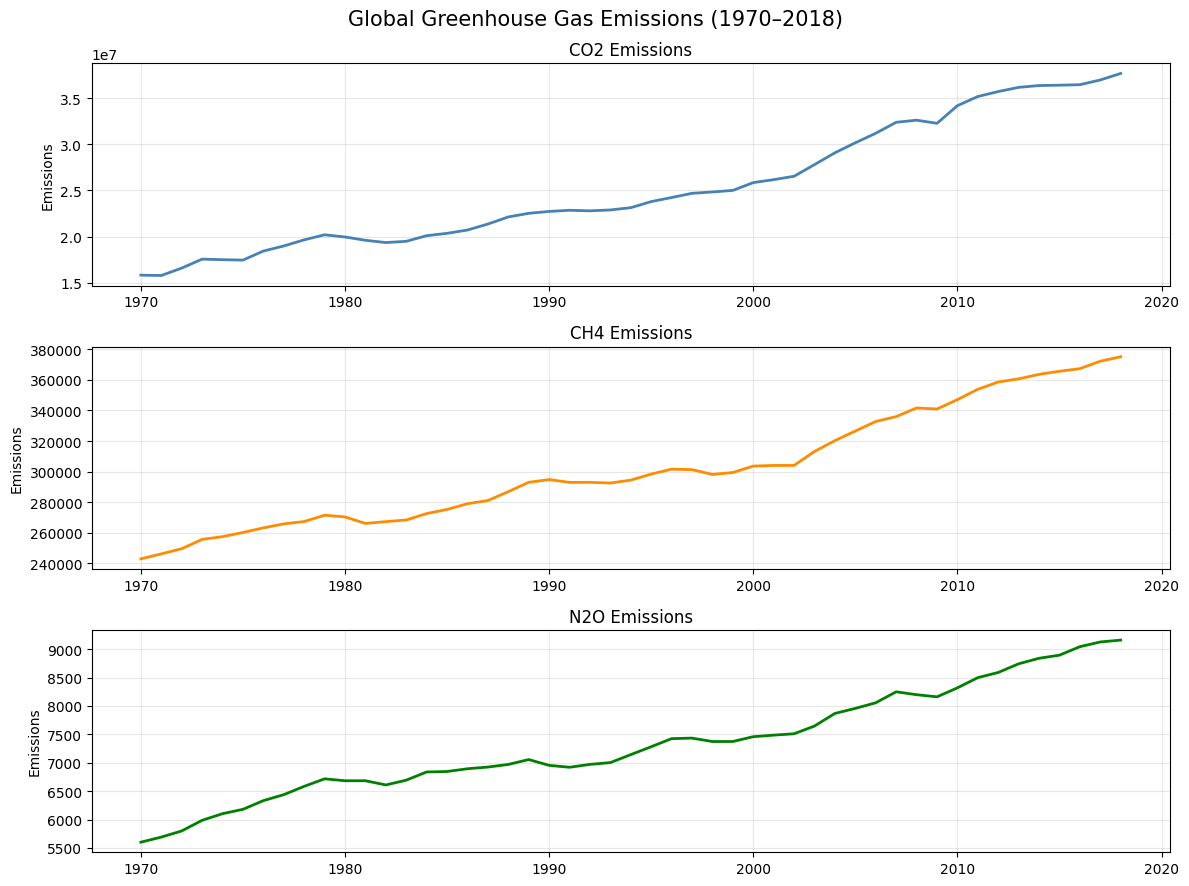

Plot saved.


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle('Global Greenhouse Gas Emissions (1970–2018)', fontsize=15)

for ax, col, color in zip(axes, ['CO2', 'CH4', 'N2O'], ['steelblue', 'darkorange', 'green']):
    ax.plot(df_var.index, df_var[col], color=color, linewidth=2)
    ax.set_title(f'{col} Emissions', fontsize=12)
    ax.set_ylabel('Emissions')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('var_raw_series.png', dpi=150)
plt.show()
print("Plot saved.")

In [13]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print(f"  RESULT: STATIONARY (p < 0.05) ✓")
    else:
        print(f"  RESULT: NON-STATIONARY (p >= 0.05) — differencing needed")

print("=== RAW SERIES ===")
for col in ['CO2', 'CH4', 'N2O']:
    adf_test(df_var[col], col)

=== RAW SERIES ===

--- ADF Test: CO2 ---
  ADF Statistic : 0.5889
  p-value       : 0.9873
  RESULT: NON-STATIONARY (p >= 0.05) — differencing needed

--- ADF Test: CH4 ---
  ADF Statistic : 0.6567
  p-value       : 0.9889
  RESULT: NON-STATIONARY (p >= 0.05) — differencing needed

--- ADF Test: N2O ---
  ADF Statistic : 1.2461
  p-value       : 0.9963
  RESULT: NON-STATIONARY (p >= 0.05) — differencing needed


In [14]:
# Subtract each year's value from the next year's value
df_diff = df_var.diff().dropna()

print("Shape after differencing:", df_diff.shape)
print("\nFirst 5 rows:")
print(df_diff.head())

# Now test stationarity again on the differenced series
print("\n=== DIFFERENCED SERIES ===")
for col in ['CO2', 'CH4', 'N2O']:
    adf_test(df_diff[col], col)

Shape after differencing: (48, 3)

First 5 rows:
                      CO2          CH4         N2O
1971-01-01  -37689.634584  3247.344112   89.397451
1972-01-01  803424.335965  3375.477518  108.449561
1973-01-01  970206.146141  6140.395055  187.234518
1974-01-01  -59354.214390  1772.427157  116.711272
1975-01-01  -44957.136246  2745.849761   76.588715

=== DIFFERENCED SERIES ===

--- ADF Test: CO2 ---
  ADF Statistic : -4.8709
  p-value       : 0.0000
  RESULT: STATIONARY (p < 0.05) ✓

--- ADF Test: CH4 ---
  ADF Statistic : -4.6263
  p-value       : 0.0001
  RESULT: STATIONARY (p < 0.05) ✓

--- ADF Test: N2O ---
  ADF Statistic : -4.8724
  p-value       : 0.0000
  RESULT: STATIONARY (p < 0.05) ✓


In [15]:
# Fit a VAR model just to select lag order
model_selector = VAR(df_diff)

# Test lags 1 through 10
lag_results = model_selector.select_order(maxlags=10)
print(lag_results.summary())

# Extract the recommended lag from AIC
optimal_lag = lag_results.selected_orders['aic']
print(f"\nOptimal lag order (AIC): {optimal_lag}")

# Safety check: if optimal_lag is 0, use 1
if optimal_lag == 0:
    optimal_lag = 1
    print("Defaulting to lag=1")

print(f"\nFinal lag order to be used: {optimal_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        49.60      49.73*  3.478e+21*      49.65*
1        49.68       50.20   3.766e+21       49.86
2        49.74       50.64   4.049e+21       50.06
3        49.90       51.19   4.866e+21       50.36
4        49.81       51.49   4.670e+21       50.41
5        49.88       51.94   5.415e+21       50.61
6        50.12       52.58   7.880e+21       51.00
7        49.80       52.65   6.967e+21       50.82
8        49.51       52.74   6.978e+21       50.66
9        49.33       52.95   9.155e+21       50.62
10      48.42*       52.43   7.675e+21       49.85
--------------------------------------------------

Optimal lag order (AIC): 10

Final lag order to be used: 10


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [16]:
# Override lag to 3 — safe for our 48-observation dataset
optimal_lag = 3
print(f"Using lag order: {optimal_lag}")

# 80% training, 20% testing
n = len(df_diff)
split = int(n * 0.8)

train = df_diff.iloc[:split]
test  = df_diff.iloc[split:]

print(f"\nTotal observations : {n}")
print(f"Training set       : {len(train)} years ({df_diff.index[0].year}–{df_diff.index[split-1].year})")
print(f"Test set           : {len(test)} years ({df_diff.index[split].year}–{df_diff.index[-1].year})")

Using lag order: 3

Total observations : 48
Training set       : 38 years (1971–2008)
Test set           : 10 years (2009–2018)


In [17]:
# Fit VAR on training data
var_model = VAR(train)
var_results = var_model.fit(maxlags=optimal_lag, ic='aic')

print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 09, Jun, 2026
Time:                     11:50:01
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    49.5110
Nobs:                     38.0000    HQIC:                   49.4277
Log likelihood:          -1097.01    FPE:                2.79404e+21
AIC:                      49.3817    Det(Omega_mle):     2.58458e+21
--------------------------------------------------------------------
Results for equation CO2
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const    441924.044128     70979.094149            6.226           0.000

Results for equation CH4
           coefficient       std. error           t-stat            prob
--------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


In [18]:
# Force exactly lag 3 by using fit(3) directly instead of ic='aic'
var_results = var_model.fit(3)

print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 09, Jun, 2026
Time:                     11:53:32
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    51.2504
Nobs:                     35.0000    HQIC:                   50.3775
Log likelihood:          -992.541    FPE:                5.01308e+21
AIC:                      49.9173    Det(Omega_mle):     2.35869e+21
--------------------------------------------------------------------
Results for equation CO2
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const     176973.936026    119763.565360            1.478           0.139
L1.CO2         0.436910         0.291957            1.496           0.135
L1.CH4        53.685810        39.329525            1.365           0.172
L1.N2O      -529

In [19]:
print("=" * 60)
print("GRANGER CAUSALITY TESTS")
print("p < 0.05 means that gas helps predict the other")
print("=" * 60)

gas_pairs = [
    (['CO2', 'CH4'], "Does CH4 help predict CO2?"),
    (['CO2', 'N2O'], "Does N2O help predict CO2?"),
    (['CH4', 'CO2'], "Does CO2 help predict CH4?"),
    (['CH4', 'N2O'], "Does N2O help predict CH4?"),
    (['N2O', 'CO2'], "Does CO2 help predict N2O?"),
    (['N2O', 'CH4'], "Does CH4 help predict N2O?"),
]

for cols, label in gas_pairs:
    print(f"\n{label}")
    grangercausalitytests(df_diff[cols], maxlag=3, verbose=True)

GRANGER CAUSALITY TESTS
p < 0.05 means that gas helps predict the other

Does CH4 help predict CO2?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2857  , p=0.5957  , df_denom=44, df_num=1
ssr based chi2 test:   chi2=0.3052  , p=0.5807  , df=1
likelihood ratio test: chi2=0.3042  , p=0.5813  , df=1
parameter F test:         F=0.2857  , p=0.5957  , df_denom=44, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.3442  , p=0.2720  , df_denom=41, df_num=2
ssr based chi2 test:   chi2=3.0162  , p=0.2213  , df=2
likelihood ratio test: chi2=2.9214  , p=0.2321  , df=2
parameter F test:         F=1.3442  , p=0.2720  , df_denom=41, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1550  , p=0.3395  , df_denom=38, df_num=3
ssr based chi2 test:   chi2=4.1034  , p=0.2505  , df=3
likelihood ratio test: chi2=3.9270  , p=0.2695  , df=3
parameter F test:         F=1.1550  , p=0.3395  , df_denom=38, df_num=3


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get last 3 rows of training data as input (equal to lag order)
lag_order = var_results.k_ar
forecast_input = train.values[-lag_order:]

# Forecast for length of test set
fc = var_results.forecast(y=forecast_input, steps=len(test))
fc_df = pd.DataFrame(fc, index=test.index, columns=['CO2_fc', 'CH4_fc', 'N2O_fc'])

print("=" * 50)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 50)

for i, gas in enumerate(['CO2', 'CH4', 'N2O']):
    actual    = test[gas].values
    predicted = fc_df.iloc[:, i].values

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (np.abs(actual) + 1e-10))) * 100

    print(f"\n{gas}:")
    print(f"  MAE  = {mae:,.2f}")
    print(f"  RMSE = {rmse:,.2f}")
    print(f"  MAPE = {mape:.2f}%")

MODEL PERFORMANCE ON TEST SET

CO2:
  MAE  = 402,871.69
  RMSE = 525,757.59
  MAPE = 240.60%

CH4:
  MAE  = 1,577.26
  RMSE = 1,845.96
  MAPE = 64.18%

N2O:
  MAE  = 70.14
  RMSE = 84.51
  MAPE = 72.73%


In [21]:
# Use last 3 rows of full differenced series as input
forecast_input_full = df_diff.values[-var_results.k_ar:]

# Forecast 10 steps ahead
future_fc = var_results.forecast(y=forecast_input_full, steps=10)

# Build year index 2019–2028
future_years = pd.date_range(start='2019', periods=10, freq='YS')

# Store differenced forecasts
future_diff_df = pd.DataFrame(future_fc, index=future_years,
                               columns=['CO2_diff', 'CH4_diff', 'N2O_diff'])

print("Forecasted CHANGES (differenced) for 2019–2028:")
print(future_diff_df.round(2))

# Un-difference: recover absolute levels by adding last actual value (2018)
last_actual = df_var.iloc[-1]
print(f"\nLast known values (2018):")
print(last_actual)

future_levels = pd.DataFrame(index=future_years, columns=['CO2', 'CH4', 'N2O'])

for col, diff_col in zip(['CO2', 'CH4', 'N2O'], ['CO2_diff', 'CH4_diff', 'N2O_diff']):
    future_levels[col] = last_actual[col] + future_diff_df[diff_col].cumsum()

future_levels = future_levels.astype(float)

print("\nForecasted ABSOLUTE LEVELS for 2019–2028:")
print(future_levels.round(2))

Forecasted CHANGES (differenced) for 2019–2028:
             CO2_diff  CH4_diff  N2O_diff
2019-01-01  483658.93   1076.27     81.34
2020-01-01  307603.91   2829.01     34.95
2021-01-01  473704.84   2774.68     58.72
2022-01-01  574681.32   2726.88     73.59
2023-01-01  413236.42   2771.54     52.88
2024-01-01  410717.80   2327.33     54.87
2025-01-01  471558.91   2587.78     55.19
2026-01-01  445803.93   2612.21     58.38
2027-01-01  433439.87   2500.72     57.84
2028-01-01  436828.33   2544.87     54.57

Last known values (2018):
CO2    3.768353e+07
CH4    3.752105e+05
N2O    9.159714e+03
Name: 2018-01-01 00:00:00, dtype: float64

Forecasted ABSOLUTE LEVELS for 2019–2028:
                    CO2        CH4      N2O
2019-01-01  38167184.65  376286.73  9241.05
2020-01-01  38474788.56  379115.74  9276.00
2021-01-01  38948493.40  381890.42  9334.72
2022-01-01  39523174.72  384617.30  9408.31
2023-01-01  39936411.14  387388.84  9461.19
2024-01-01  40347128.94  389716.16  9516.06
2025-01-01

In [22]:
# Standard IPCC AR5 GWP values (100-year horizon)
GWP_CH4 = 28    # 1 unit CH4 = 28 units CO2 in warming effect
GWP_N2O = 265   # 1 unit N2O = 265 units CO2 in warming effect

# Calculate CO2e for forecast period
future_levels['CO2e'] = (
    future_levels['CO2'] * 1 +
    future_levels['CH4'] * GWP_CH4 +
    future_levels['N2O'] * GWP_N2O
)

# Also calculate CO2e for historical period
df_var['CO2e'] = (
    df_var['CO2'] * 1 +
    df_var['CH4'] * GWP_CH4 +
    df_var['N2O'] * GWP_N2O
)

print("=" * 55)
print("COMPLETE FORECAST WITH CO2-EQUIVALENT (2019–2028)")
print("=" * 55)
print(future_levels.round(2).to_string())

print(f"\nHistorical CO2e in 2018 : {df_var['CO2e'].iloc[-1]:,.2f}")
print(f"Forecasted CO2e in 2028 : {future_levels['CO2e'].iloc[-1]:,.2f}")

growth = ((future_levels['CO2e'].iloc[-1] - df_var['CO2e'].iloc[-1]) / df_var['CO2e'].iloc[-1]) * 100
print(f"Projected CO2e growth   : {growth:.2f}% over 10 years")

COMPLETE FORECAST WITH CO2-EQUIVALENT (2019–2028)
                    CO2        CH4      N2O         CO2e
2019-01-01  38167184.65  376286.73  9241.05  51152092.48
2020-01-01  38474788.56  379115.74  9276.00  51548169.86
2021-01-01  38948493.40  381890.42  9334.72  52115125.50
2022-01-01  39523174.72  384617.30  9408.31  52785661.34
2023-01-01  39936411.14  387388.84  9461.19  53290513.62
2024-01-01  40347128.94  389716.16  9516.06  53780936.70
2025-01-01  40818687.85  392303.94  9571.24  54339577.90
2026-01-01  41264491.78  394916.16  9629.62  54873993.57
2027-01-01  41697931.64  397416.88  9687.46  55392782.35
2028-01-01  42134759.97  399961.75  9742.04  55915328.50

Historical CO2e in 2018 : 50,616,742.90
Forecasted CO2e in 2028 : 55,915,328.50
Projected CO2e growth   : 10.47% over 10 years


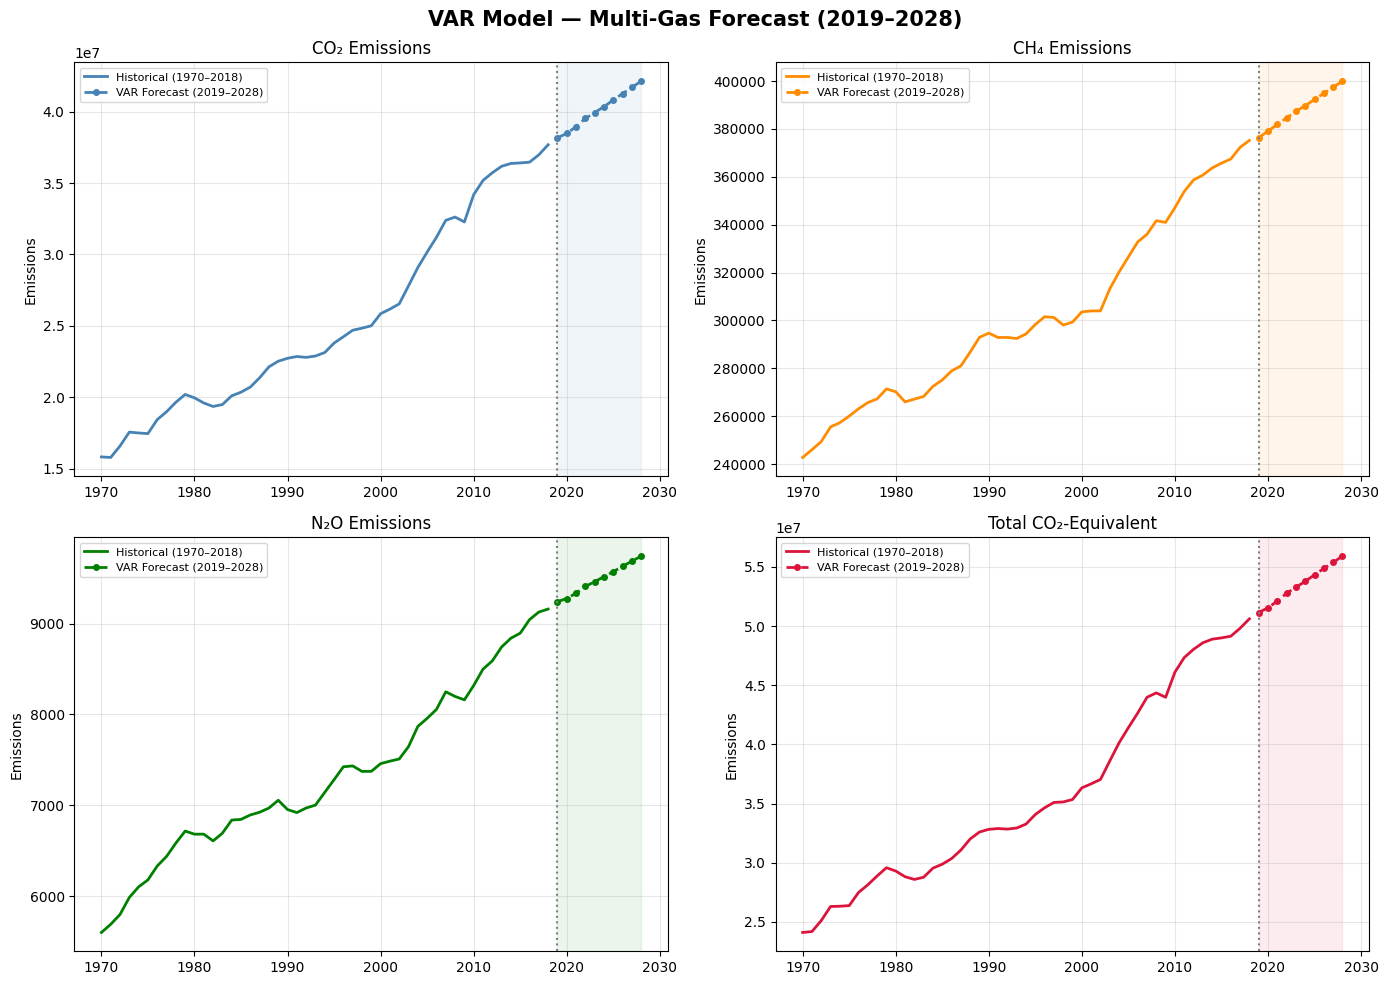

Forecast plot saved.


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VAR Model — Multi-Gas Forecast (2019–2028)', fontsize=15, fontweight='bold')

plot_config = [
    ('CO2', 'steelblue',   'CO₂ Emissions'),
    ('CH4', 'darkorange',  'CH₄ Emissions'),
    ('N2O', 'green',       'N₂O Emissions'),
    ('CO2e','crimson',     'Total CO₂-Equivalent'),
]

for ax, (col, color, title) in zip(axes.flatten(), plot_config):
    # Plot historical
    if col != 'CO2e':
        ax.plot(df_var.index, df_var[col], color=color,
                linewidth=2, label='Historical (1970–2018)')
    else:
        ax.plot(df_var.index, df_var['CO2e'], color=color,
                linewidth=2, label='Historical (1970–2018)')

    # Plot forecast
    ax.plot(future_levels.index, future_levels[col], '--',
            color=color, linewidth=2, marker='o',
            markersize=4, label='VAR Forecast (2019–2028)')

    # Shade forecast region
    ax.axvspan(future_levels.index[0], future_levels.index[-1],
               alpha=0.08, color=color)

    # Vertical line separating history from forecast
    ax.axvline(x=pd.Timestamp('2019'), color='gray',
               linestyle=':', linewidth=1.5)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Emissions')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('var_forecast.png', dpi=150)
plt.show()
print("Forecast plot saved.")

In [24]:
print("=" * 55)
print("RESIDUAL DIAGNOSTICS — DURBIN-WATSON TEST")
print("=" * 55)
print("Ideal value: close to 2.0 = no autocorrelation")
print("< 1.5 = positive autocorrelation (problem)")
print("> 2.5 = negative autocorrelation (problem)")
print("-" * 55)

dw_stats = durbin_watson(var_results.resid)

for gas, stat in zip(['CO2', 'CH4', 'N2O'], dw_stats):
    if 1.5 <= stat <= 2.5:
        status = "✓ GOOD"
    elif stat < 1.5:
        status = "⚠ positive autocorrelation"
    else:
        status = "⚠ negative autocorrelation"
    print(f"  {gas}: {stat:.4f}  {status}")

RESIDUAL DIAGNOSTICS — DURBIN-WATSON TEST
Ideal value: close to 2.0 = no autocorrelation
< 1.5 = positive autocorrelation (problem)
> 2.5 = negative autocorrelation (problem)
-------------------------------------------------------
  CO2: 1.5370  ✓ GOOD
  CH4: 1.7700  ✓ GOOD
  N2O: 1.6759  ✓ GOOD


In [25]:
# Save the trained VAR model
with open('var_model.pkl', 'wb') as f:
    pickle.dump(var_results, f)

# Save forecast to CSV
future_levels.to_csv('var_forecast_2019_2028.csv')

# Save historical + forecast combined for easy comparison
combined = pd.DataFrame({
    'CO2':  list(df_var['CO2'])  + list(future_levels['CO2']),
    'CH4':  list(df_var['CH4'])  + list(future_levels['CH4']),
    'N2O':  list(df_var['N2O'])  + list(future_levels['N2O']),
    'CO2e': list(df_var['CO2e']) + list(future_levels['CO2e']),
}, index=list(df_var.index) + list(future_levels.index))

combined.index.name = 'Year'
combined.to_csv('var_full_series.csv')

print("=" * 50)
print("ALL OUTPUTS SAVED SUCCESSFULLY")
print("=" * 50)
print("  var_model.pkl              — trained VAR model")
print("  var_forecast_2019_2028.csv — forecast table")
print("  var_full_series.csv        — historical + forecast")
print("  var_raw_series.png         — historical plots")
print("  var_forecast.png           — forecast plots")
print("\n✓ VAR multi-gas forecasting complete!")

ALL OUTPUTS SAVED SUCCESSFULLY
  var_model.pkl              — trained VAR model
  var_forecast_2019_2028.csv — forecast table
  var_full_series.csv        — historical + forecast
  var_raw_series.png         — historical plots
  var_forecast.png           — forecast plots

✓ VAR multi-gas forecasting complete!
